## TESTY

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import seaborn as sns

from iris_segmentation import IrisSegmentation, IrisEncoder

In [ ]:
def evaluate(f=0.95):
    iris = IrisSegmentation()
    encoder = IrisEncoder()
    X_PUPIL = 5  # próg źrenicy 
    X_IRIS  = 1.2   # próg tęczówki TU JEST PROBLEM
    CLOSE_SIZE = 10   # zamknięcie 
    OPEN_SIZE  = 7    # otwarcie   
    RADIAL_RES  = 64
    ANGULAR_RES = 360

    folder = "baza_oczu"
    image_paths = []
    labels = []
    people = ["aeval", "bryanl", "christinel", "chualsl", "fional"]
    for person in people:
        for img_id in range(1, 5):     
            nazwa_pliku = f"{person}{img_id}.bmp" 
            image_paths.append(os.path.join(folder, nazwa_pliku)) 
            
            krotka_nazwa = person[:6].capitalize() 
            labels.append(f"{krotka_nazwa}_{img_id}")

    codes = []
    print("Generowanie kodów tęczówki dla 20 zdjęć...")
    for i, path in enumerate(image_paths):
        print(f"[{i+1}/20] Przetwarzanie: {path}")
        try:
            img = Image.open(path)
            result = iris.segment(img,  X_pupil=X_PUPIL,
                X_iris=X_IRIS,
                close_size_pupil=CLOSE_SIZE,
                open_size_pupil=OPEN_SIZE,
                radial_res=RADIAL_RES,
                angular_res=ANGULAR_RES,
                verbose=True)
            unwrapped = result['unwrapped']
            
            result_img = iris.draw_result(img, result)

            fig, axes = plt.subplots(1, 5, figsize=(24, 5))
            fig.suptitle('Segmentacja tęczówki – wyniki', fontsize=13)
            data = [
                (result['gray'],               'gray', 'Szarość'),
                (result['binary_pupil'],       'gray', 'Binaryzacja\nźrenicy'),
                (result['binary_pupil_clean'], 'gray', 'Maska źrenicy\n(po morfologii)'),
                (np.array(result_img),         None,   'Detekcja okręgów'),
                (result['unwrapped'],          'gray', 'Rozwinięta\ntęczówka'),
            ]
            for ax, (img, cmap, title) in zip(axes, data):
                ax.imshow(img, cmap=cmap)
                ax.set_title(title)
                ax.axis('off')
            plt.tight_layout()
            plt.show()

            code = encoder.encode(unwrapped, f_gabor=f) 
            codes.append(code)

            drawn_code_image = encoder.draw_code(code, scale_factor=10)
            plt.figure(figsize=(10, 5))         # 
            plt.imshow(drawn_code_image, cmap='gray')
            plt.axis('off')                     
            plt.title("Kod tęczówkip")
            plt.show()
        except Exception as e:
            print(f"Błąd przy przetwarzaniu {path}: {e}")
            codes.append(np.zeros((8, 256))) 

    # 3. Obliczanie dystansów (każdy z każdym)
    num_images = len(codes)
    matrix = np.zeros((num_images, num_images))
    
    print("\nObliczanie macierzy dystansów (400 porównań)...")
    for i in range(num_images):
        for j in range(num_images):
            # Na przekątnej (to samo zdjęcie) wynik wynosi 0
            if i == j:
                matrix[i, j] = 0.0
            else:
                matrix[i, j] = encoder.calculate_hamming_distance(codes[i], codes[j])

    plt.figure(figsize=(10, 8))
    
    ax = sns.heatmap(matrix, annot=False, cmap='RdYlGn_r', vmin=0.0, vmax=0.6,
                     xticklabels=labels, yticklabels=labels)

    for i in range(4, num_images, 4):
        ax.axhline(i, color='white', lw=2)
        ax.axvline(i, color='white', lw=2)

    plt.title("Macierz Dystansów Hamminga (5 Osób x 4 Zdjęcia)", fontsize=14, pad=15)
    
    plt.tight_layout()
    
    plt.savefig("macierz_wynikow.png", dpi=300)
    print("Zapisano wykres jako 'macierz_wynikow.png'!")
    plt.show()


Generowanie kodów tęczówki dla 20 zdjęć...
[1/20] Przetwarzanie: baza_oczu\aeval1.bmp
NOWA WERSJA
NOWA WERSJA
[INFO] Środek:  (155, 118)
[INFO] Źrenica: r = 22 px
[INFO] Tęczówka: r = 82 px


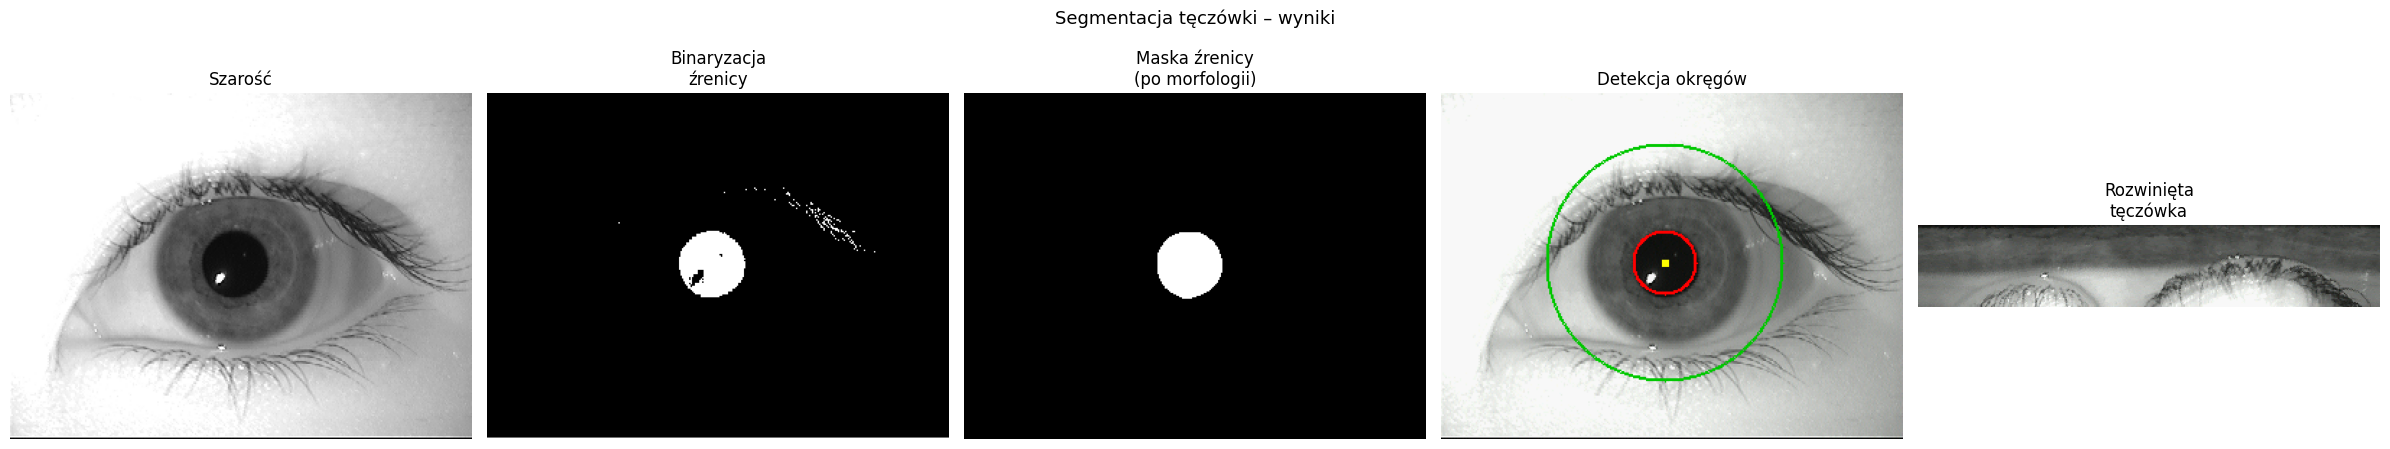

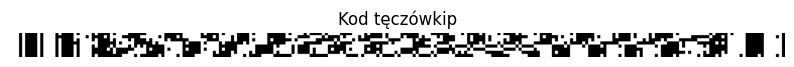

[2/20] Przetwarzanie: baza_oczu\aeval2.bmp
NOWA WERSJA
NOWA WERSJA
[INFO] Środek:  (167, 120)
[INFO] Źrenica: r = 23 px
[INFO] Tęczówka: r = 83 px


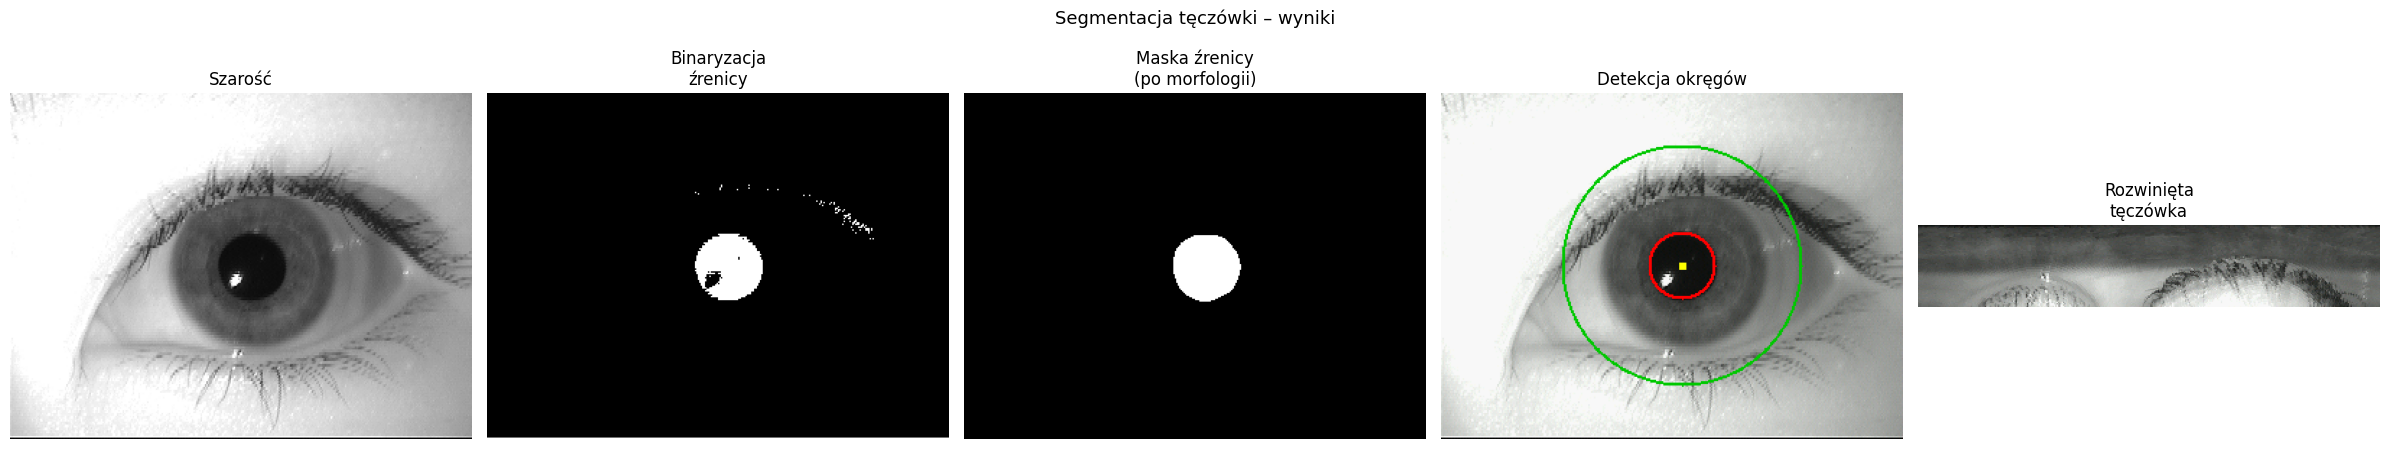

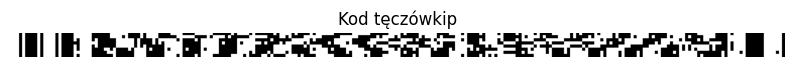

[3/20] Przetwarzanie: baza_oczu\aeval3.bmp
NOWA WERSJA
NOWA WERSJA
[INFO] Środek:  (136, 121)
[INFO] Źrenica: r = 22 px
[INFO] Tęczówka: r = 84 px


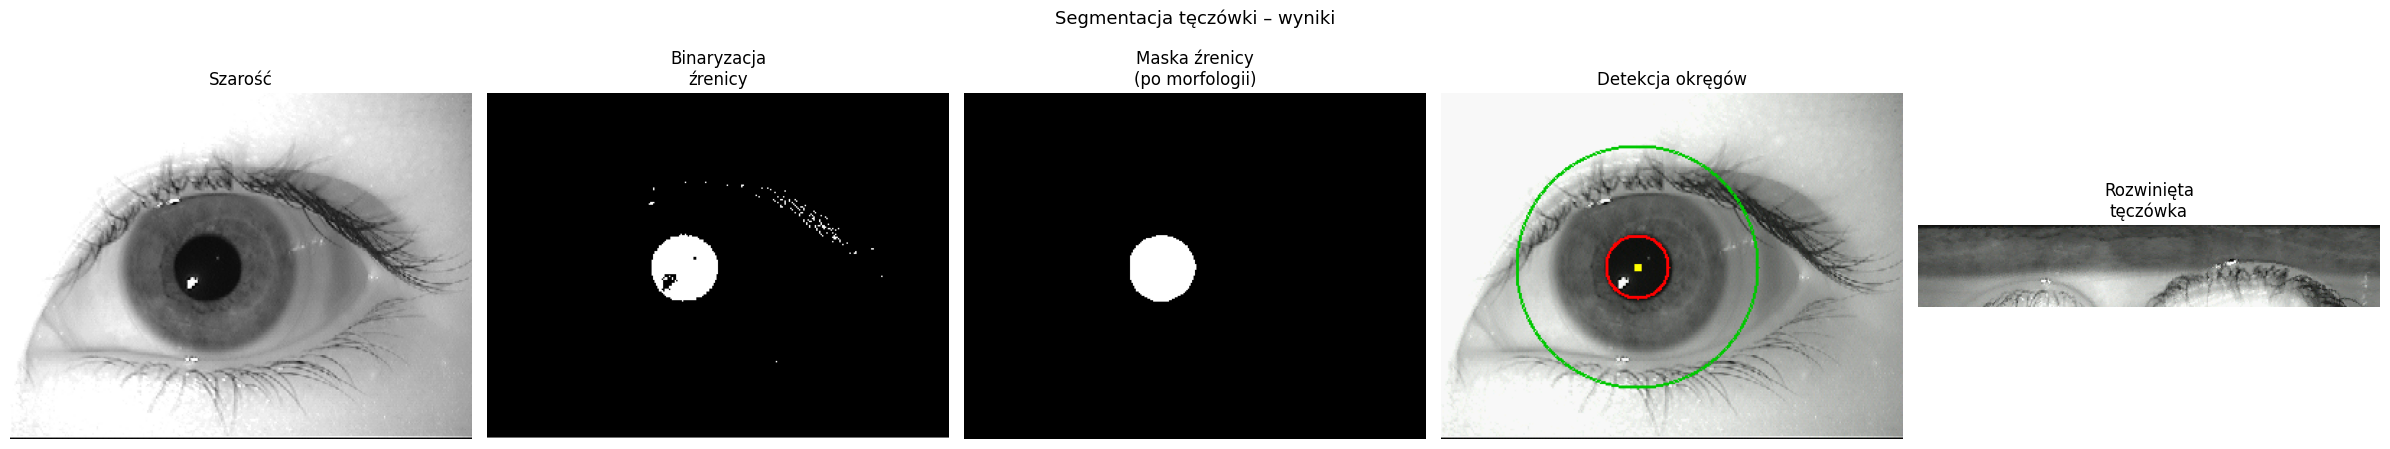

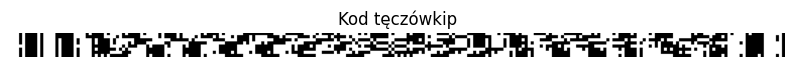

[4/20] Przetwarzanie: baza_oczu\aeval4.bmp
NOWA WERSJA
NOWA WERSJA
[INFO] Środek:  (142, 130)
[INFO] Źrenica: r = 24 px
[INFO] Tęczówka: r = 80 px


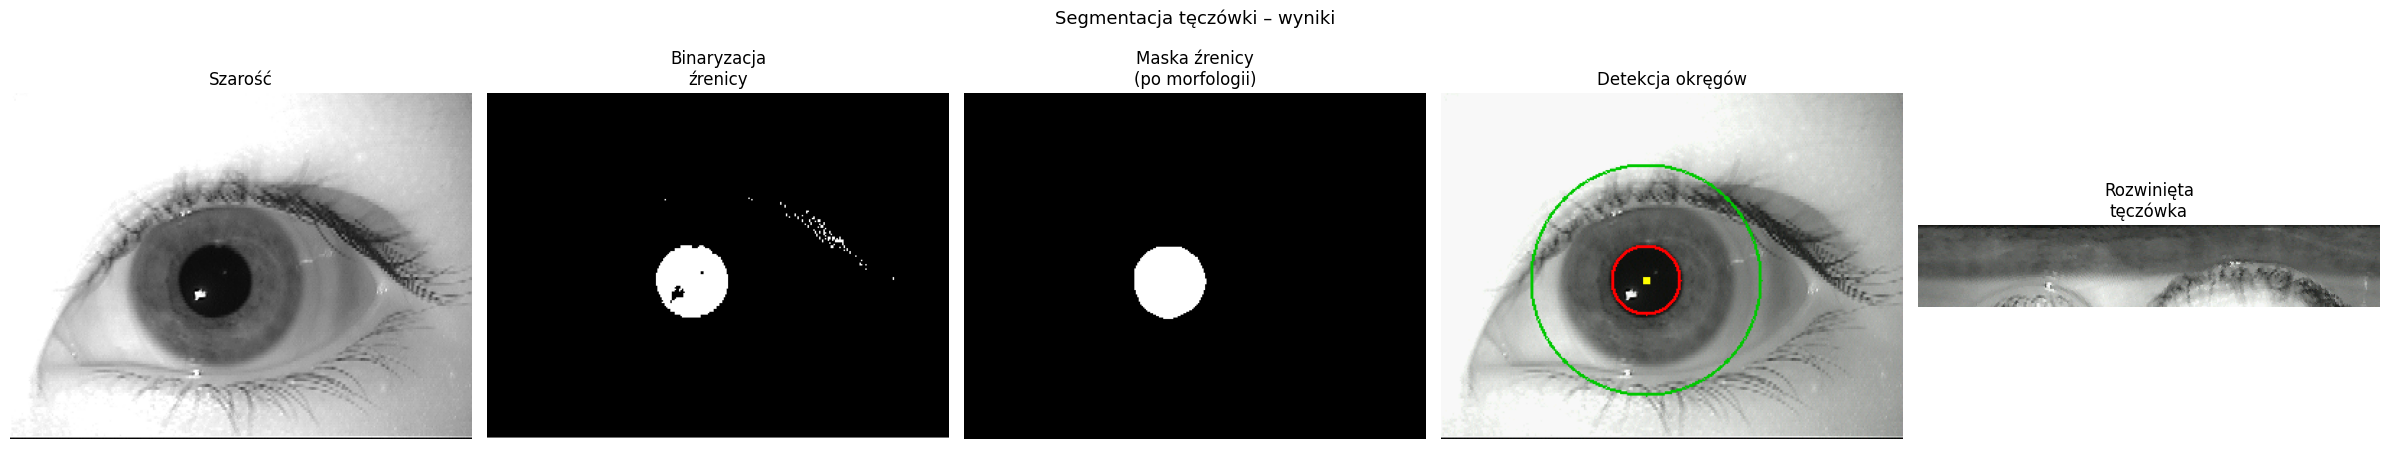

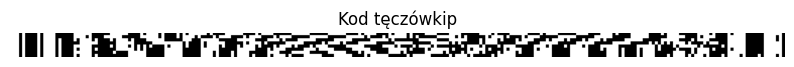

[5/20] Przetwarzanie: baza_oczu\bryanl1.bmp
NOWA WERSJA
NOWA WERSJA
[INFO] Środek:  (147, 123)
[INFO] Źrenica: r = 23 px
[INFO] Tęczówka: r = 81 px


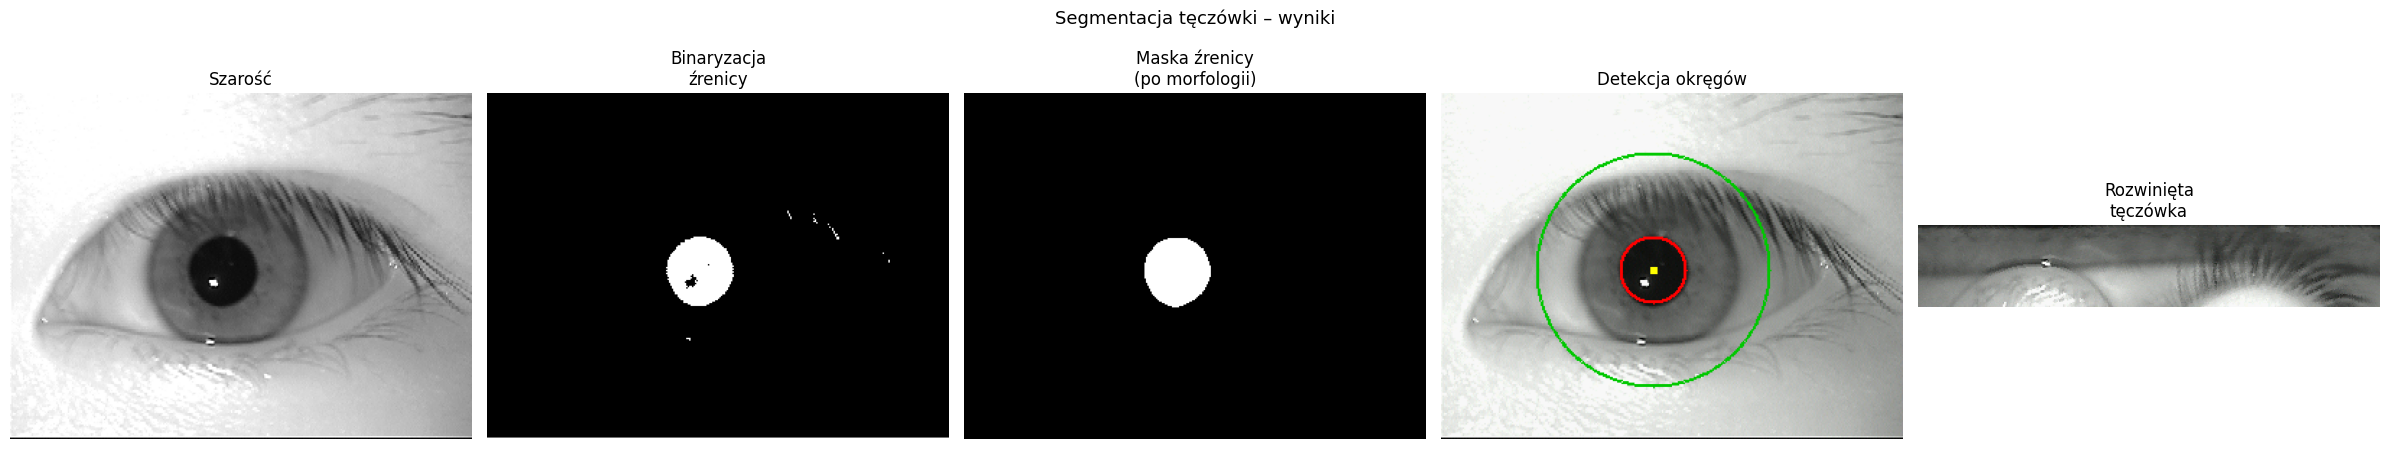

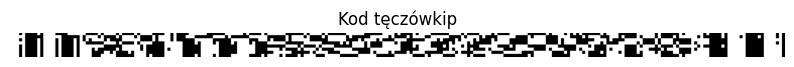

[6/20] Przetwarzanie: baza_oczu\bryanl2.bmp


KeyboardInterrupt: 

In [3]:
evaluate(0.95)